In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-10 17:51:51.726640


# Train scVI model

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


## Set paths, import data

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = os.path.join(base_dir, 'data/h5ad/export_01/04_filtered')
scvi_dir = os.path.join(base_dir, 'scvi/01_model')
output_dir = os.path.join(base_dir, 'data/h5ad/export_02')

os.makedirs(output_dir, exist_ok=True)

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-filtered.h5ad'))

In [6]:
adata

AnnData object with n_obs × n_vars = 93854 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'

## Prepare adata

In [7]:
adata.X[:5, :5].toarray()

array([[6.6963024, 0.       , 7.6118517, 9.046559 , 0.       ],
       [0.       , 0.       , 0.       , 9.5951805, 0.       ],
       [0.       , 8.247428 , 0.       , 8.247428 , 0.       ],
       [7.686919 , 7.686919 , 0.       , 8.379837 , 0.       ],
       [0.       , 8.047509 , 0.       , 9.433564 , 0.       ]],
      dtype=float32)

In [8]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers["counts"].copy()

print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: True
adata.X has only whole numbers: True


In [9]:
adata.X[:5, :5].toarray()

array([[ 2.,  0.,  5., 21.,  0.],
       [ 0.,  0.,  0., 33.,  0.],
       [ 0.,  1.,  0.,  1.,  0.],
       [ 1.,  1.,  0.,  2.,  0.],
       [ 0.,  1.,  0.,  4.,  0.]], dtype=float32)

## scVI

#### Train model

In [10]:
# Set up AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts",  # Use raw count data
    batch_key = 'slide'
)

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [11]:
# Initialize model
model = scvi.model.SCVI(
    adata,
    n_layers=2,  # Two-layer neural network
    n_latent=30,  # Latent space size
    gene_likelihood = "nb" # TRM paper
)

In [12]:
# Train SCVI with updated parameters
model.train(
    early_stopping=True,
    accelerator = "gpu",
    early_stopping_patience=5,  # Stop if no improvement for 5 epochs
    early_stopping_min_delta=1e-4,  # Require small improvement to continue
    enable_progress_bar=True
)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a

Epoch 85/85: 100%|██████████| 85/85 [08:41<00:00,  6.19s/it, v_num=1, train_loss_step=241, train_loss_epoch=238]

`Trainer.fit` stopped: `max_epochs=85` reached.


Epoch 85/85: 100%|██████████| 85/85 [08:41<00:00,  6.14s/it, v_num=1, train_loss_step=241, train_loss_epoch=238]


In [13]:
model.save(scvi_dir, prefix='01_scvi_')

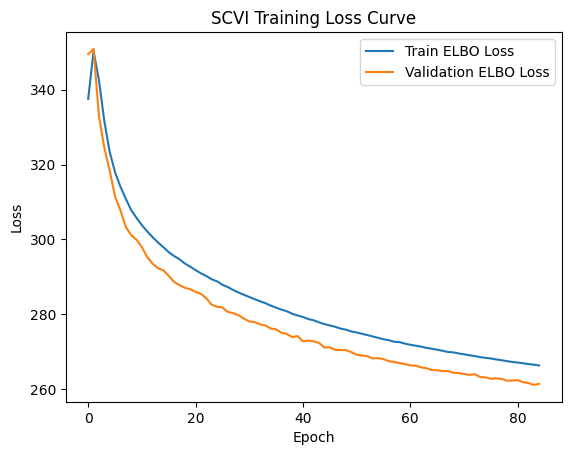

In [14]:
plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("SCVI Training Loss Curve")
plt.show()

## Extract latent representation, save

In [15]:
# add scVI latent dimensions to adata.obsm
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)
adata.obsm['X_scVI'].shape

# Note scvi no longer supports mde embedding

(93854, 30)

## Export

In [16]:
# save adata with scvi dims
filename = os.path.join(output_dir, 'adata-scvi.h5ad') # saved with raw layer active
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata.write_h5ad(filename, compression='gzip')

## Session info

In [17]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
